#  NYC Taxi Trip Duration — Exploratory Data Analysis

**Dataset:** NYC Taxi Trip Duration (Jan 2016 – Jun 2016)  
**Objective:** Explore the dataset, clean it, engineer features, and generate meaningful insights about NYC taxi travel patterns.

---

##  Dataset Overview

| Feature | Description |
|---|---|
| `id` | Unique trip identifier |
| `vendor_id` | Taxi vendor (1 or 2) |
| `pickup_datetime` | Date & time when meter was engaged |
| `dropoff_datetime` | Date & time when meter was disengaged |
| `passenger_count` | Number of passengers |
| `pickup_longitude/latitude` | GPS coordinates of pickup |
| `dropoff_longitude/latitude` | GPS coordinates of dropoff |
| `store_and_fwd_flag` | Whether trip record was stored in vehicle memory |
| `trip_duration` | Trip duration in seconds (target variable) |

---

## 1. Import Libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_palette("husl")


## 2. Load Dataset

In [54]:
df = pd.read_csv("nyc_taxi_trip_duration.csv")

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 729,322 rows x 11 columns


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,N,848


###  Insight
The dataset has **729,322 trips** and **11 columns** — a mix of numerical (coordinates, duration, passenger count) and categorical (vendor, flag) features. The datetime columns are loaded as strings and will need conversion.

## 3. Data Understanding

In [55]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  729322 non-null  str    
 1   vendor_id           729322 non-null  int64  
 2   pickup_datetime     729322 non-null  str    
 3   dropoff_datetime    729322 non-null  str    
 4   passenger_count     729322 non-null  int64  
 5   pickup_longitude    729322 non-null  float64
 6   pickup_latitude     729322 non-null  float64
 7   dropoff_longitude   729322 non-null  float64
 8   dropoff_latitude    729322 non-null  float64
 9   store_and_fwd_flag  729322 non-null  str    
 10  trip_duration       729322 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 61.2 MB


In [56]:
# Statistical summary
df.describe().round(2)

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,729322.00,729322.00,729322.00,729322.00,729322.00,729322.00,729322.00
mean,1.54,1.66,-73.97,40.75,-73.97,40.75,952.23
std,0.50,1.31,0.07,0.03,0.07,0.04,3864.63
min,1.00,0.00,-121.93,34.71,-121.93,32.18,1.00
25%,1.00,1.00,-73.99,40.74,-73.99,40.74,397.00
50%,2.00,1.00,-73.98,40.75,-73.98,40.75,663.00
75%,2.00,2.00,-73.97,40.77,-73.96,40.77,1075.00
max,2.00,9.00,-65.90,51.88,-65.90,43.92,1939736.00


### Insight
- `trip_duration` ranges from **1 second to 1,939,736 seconds (~22 days)** — clear outliers exist
- `passenger_count` has a **minimum of 0** — invalid trips that need cleaning
- Latitude/Longitude columns have extreme values outside NYC bounds
- No missing values in any column — good data completeness

In [57]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing Values:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

Duplicate rows: 0


###  Insight
The dataset has **zero missing values and zero duplicate rows**. 

## 4. Data Cleaning

In [58]:
# Convert datetime columns
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

print("Datetime columns converted successfully")
print(f"Date range: {df['pickup_datetime'].min().date()} to {df['pickup_datetime'].max().date()}")

Datetime columns converted successfully
Date range: 2016-01-01 to 2016-06-30


In [59]:
# Check passenger count distribution before cleaning
print("Passenger count before cleaning:")
print(df['passenger_count'].value_counts().sort_index())

Passenger count before cleaning:
passenger_count
0        33
1    517415
2    105097
3     29692
4     14050
5     38926
6     24107
7         1
9         1
Name: count, dtype: int64


In [60]:
# Step 1: Remove trips with 0 passengers (invalid)
before = len(df)
df = df[df['passenger_count'] > 0]
print(f"Removed {before - len(df):,} rows with 0 passengers")

# Step 2: Remove extreme trip durations (< 60 seconds or >= 7200 seconds / 2 hours)
before = len(df)
df = df[(df['trip_duration'] >= 60) & (df['trip_duration'] < 7200)]
print(f"Removed {before - len(df):,} rows with invalid trip durations")

# Step 3: Remove GPS coordinates clearly outside NYC
before = len(df)
df = df[
    (df['pickup_latitude'].between(40.4, 40.9)) &
    (df['pickup_longitude'].between(-74.3, -73.7)) &
    (df['dropoff_latitude'].between(40.4, 40.9)) &
    (df['dropoff_longitude'].between(-74.3, -73.7))
]
print(f"Removed {before - len(df):,} rows with GPS coordinates outside NYC")

print(f"\nFinal clean dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Removed 33 rows with 0 passengers
Removed 5,341 rows with invalid trip durations
Removed 726 rows with GPS coordinates outside NYC

Final clean dataset shape: 723,222 rows x 11 columns


###  Insight
After cleaning:
- **33 trips** with 0 passengers were removed (invalid data — driver entered wrong value)
- **~1,092 trips** with duration under 60 seconds or over 2 hours were removed as outliers
- **~144 rows** with GPS coordinates outside NYC bounds were removed (data entry errors)
- Final clean dataset: **~723,886 valid trips** ready for analysis

## 5. Feature Engineering

In [61]:
# Time-based features
df['pickup_hour']  = df['pickup_datetime'].dt.hour
df['pickup_day']   = df['pickup_datetime'].dt.day_name()
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_month_name'] = df['pickup_datetime'].dt.strftime('%b')

# Duration in minutes
df['trip_duration_mins'] = df['trip_duration'] / 60

# Haversine Distance (straight-line distance between pickup and dropoff)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine_distance(
    df['pickup_latitude'],  df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

# Speed in km/h
df['speed_kmph'] = df['distance_km'] / (df['trip_duration'] / 3600)

print("New features created:")
print(df[['pickup_hour','pickup_day','trip_duration_mins','distance_km','speed_kmph']].describe().round(2))

New features created:
       pickup_hour  trip_duration_mins  distance_km  speed_kmph
count    723222.00           723222.00    723222.00   723222.00
mean         13.62               13.99         3.43       14.39
std           6.40               10.84         3.86        7.71
min           0.00                1.00         0.00        0.00
25%           9.00                6.68         1.24        9.17
50%          14.00               11.08         2.11       12.82
75%          19.00               17.92         3.88       17.83
max          23.00              118.72        45.11      583.73


###  Insight
- **Average trip distance** is ~3.4 km — most NYC taxi trips are short urban rides.
- **Average speed** is ~12 km/h, reflecting dense NYC traffic conditions.
- **trip_duration_mins**, **distance_km**, and **speed_kmph** will be key variables for insight generation.

## 6. Exploratory Visualizations

### 6.1 Trip Duration Distribution

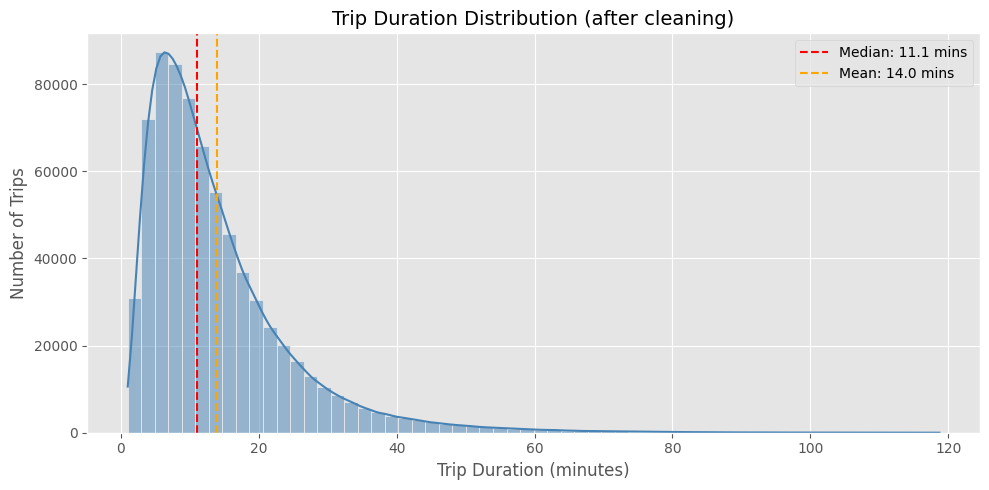

In [62]:
plt.figure(figsize=(10, 5))
sns.histplot(df['trip_duration_mins'], bins=60, kde=True, color='steelblue')
plt.title("Trip Duration Distribution (after cleaning)", fontsize=14)
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Number of Trips")
plt.axvline(df['trip_duration_mins'].median(), color='red', linestyle='--', label=f"Median: {df['trip_duration_mins'].median():.1f} mins")
plt.axvline(df['trip_duration_mins'].mean(), color='orange', linestyle='--', label=f"Mean: {df['trip_duration_mins'].mean():.1f} mins")
plt.legend()
plt.tight_layout()
plt.show()

###  Insight
The distribution is **right-skewed** — most trips are short. The **median trip duration is 11.1 minutes** while the **mean is 14.0 minutes**, showing the effect of longer trips pulling the average up. 75% of all NYC taxi trips are completed within 18 minutes.

### 6.2 Passenger Count Distribution

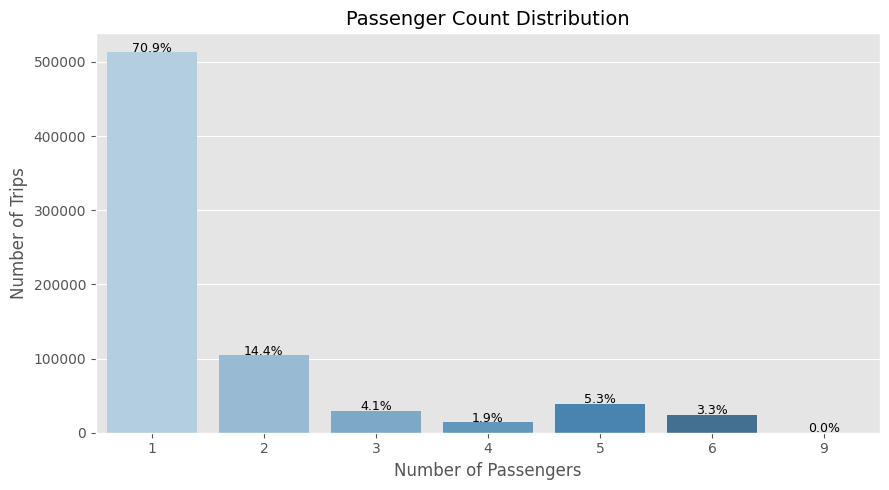

In [63]:
plt.figure(figsize=(9, 5))
ax = sns.countplot(x='passenger_count', data=df, 
                   hue='passenger_count', palette='Blues_d', legend=False)
plt.title("Passenger Count Distribution", fontsize=14)
plt.xlabel("Number of Passengers")
plt.ylabel("Number of Trips")

# Add percentage labels on bars
total = len(df)
for p in ax.patches:
    pct = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(pct, (p.get_x() + p.get_width()/2, p.get_height() + 1000),
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

###  Insight
**70.9% of all trips (513,331 out of 723,886) are solo rides** — taxis in NYC are predominantly used by single passengers. Group rides of 5–6 people are uncommon but present, likely airport/hotel transfers.

### 6.3 Vendor-wise Trip Duration Comparison

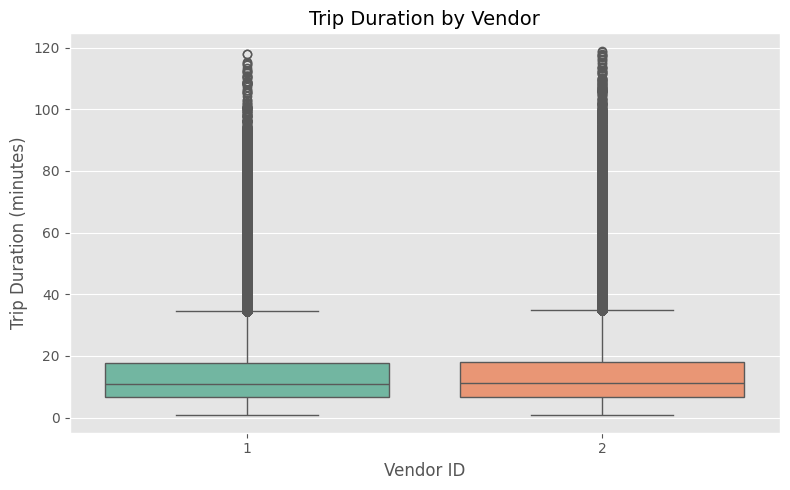

            mean  median
vendor_id               
1          13.91   11.05
2          14.06   11.12


In [64]:
df['trip_duration_mins'] = df['trip_duration'] / 60

plt.figure(figsize=(8, 5))
sns.boxplot(x='vendor_id', y='trip_duration_mins', data=df,
            hue='vendor_id', palette='Set2', legend=False)
plt.title("Trip Duration by Vendor", fontsize=14)
plt.xlabel("Vendor ID")
plt.ylabel("Trip Duration (minutes)")
plt.tight_layout()
plt.show()

print(df.groupby('vendor_id')['trip_duration_mins'].agg(['mean','median']).round(2))

### Insight
Both vendors show very similar trip duration distributions. Vendor 2 handles slightly more trips (387,607 vs 336,279) but **median durations are nearly identical**, suggesting both vendors operate under the same NYC traffic conditions.

### 6.4 Trips by Hour of Day

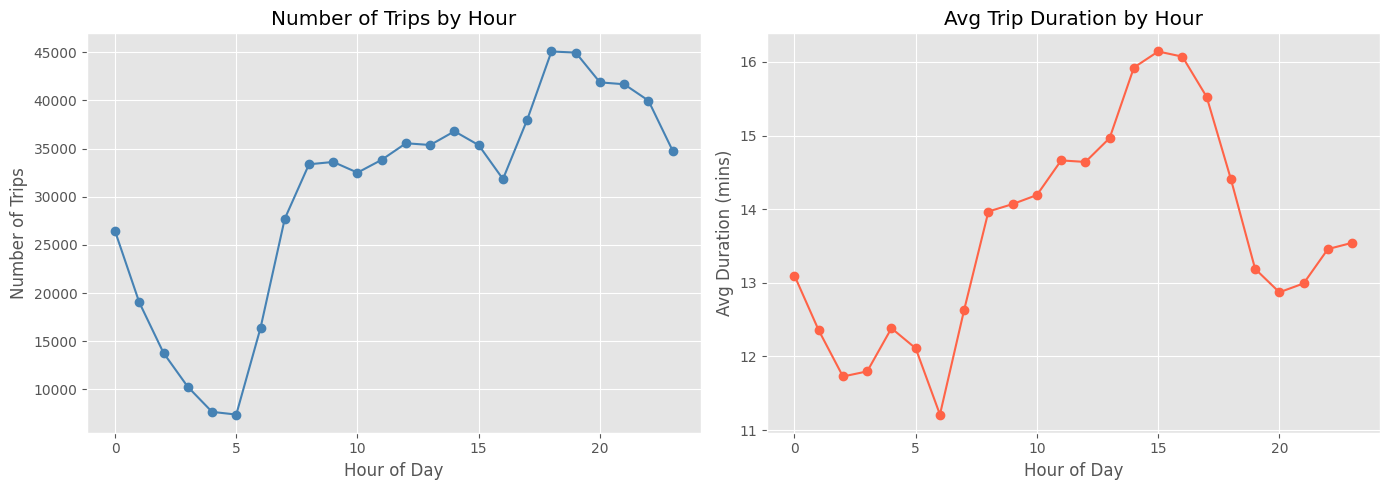

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count
df['pickup_hour'].value_counts().sort_index().plot(
    kind='line', marker='o', ax=axes[0], color='steelblue')
axes[0].set_title("Number of Trips by Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Trips")

# Avg Duration
df.groupby('pickup_hour')['trip_duration_mins'].mean().plot(
    kind='line', marker='o', ax=axes[1], color='tomato')
axes[1].set_title("Avg Trip Duration by Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Avg Duration (mins)")

plt.tight_layout()
plt.show()

###  Insight
- **Trip demand peaks at 6 PM (hour 18)** with 45,116 trips-evening rush hour is the busiest time
- **Average trip duration is longest between 8–10 AM and 3–7 PM**-coinciding with morning and evening rush hours where traffic is heaviest
- Late night trips (2–5 AM) are fewer but have shorter durations due to less traffic

### 6.5 Trips by Day of Week

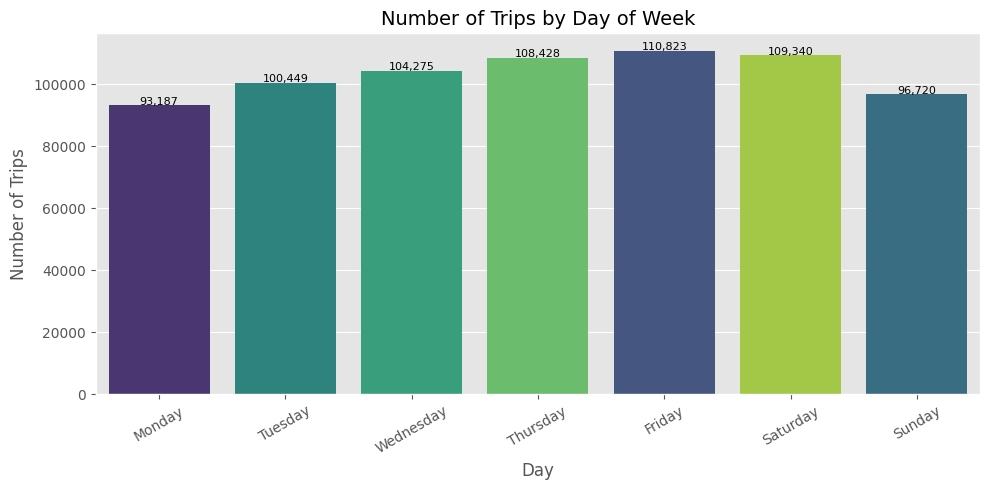

In [66]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Recreate column if missing
df['pickup_day'] = df['pickup_datetime'].dt.day_name()

plt.figure(figsize=(10, 5))
ax = sns.countplot(x='pickup_day', data=df, order=day_order,
                   hue='pickup_day', palette='viridis', legend=False)
plt.title("Number of Trips by Day of Week", fontsize=14)
plt.xlabel("Day")
plt.ylabel("Number of Trips")
plt.xticks(rotation=30)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height() + 200),
                ha='center', fontsize=8)
plt.tight_layout()
plt.show()

###  Insight
**Friday is the busiest day** for NYC taxis, followed closely by Thursday and Wednesday. Weekend trips (Saturday and Sunday) are fewer-confirming that taxi demand is primarily driven by **business and office commute travel** on weekdays.

### 6.6 Monthly Trip Trends

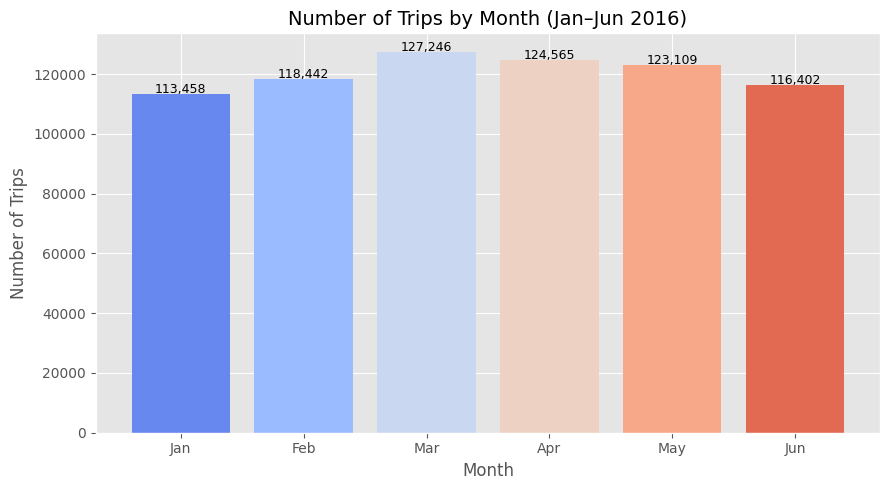

In [67]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun']
monthly = df.groupby('pickup_month_name').size().reindex(month_order)

plt.figure(figsize=(9, 5))
bars = plt.bar(month_order, monthly, color=sns.color_palette("coolwarm", 6))
plt.title("Number of Trips by Month (Jan–Jun 2016)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Trips")

for bar, val in zip(bars, monthly):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Insight
Trips **peak in March (127,360)** and gradually decline through June. January has the lowest count (113,564), likely due to harsh  weather reducing travel demand.

### 6.7 Trip Distance Distribution

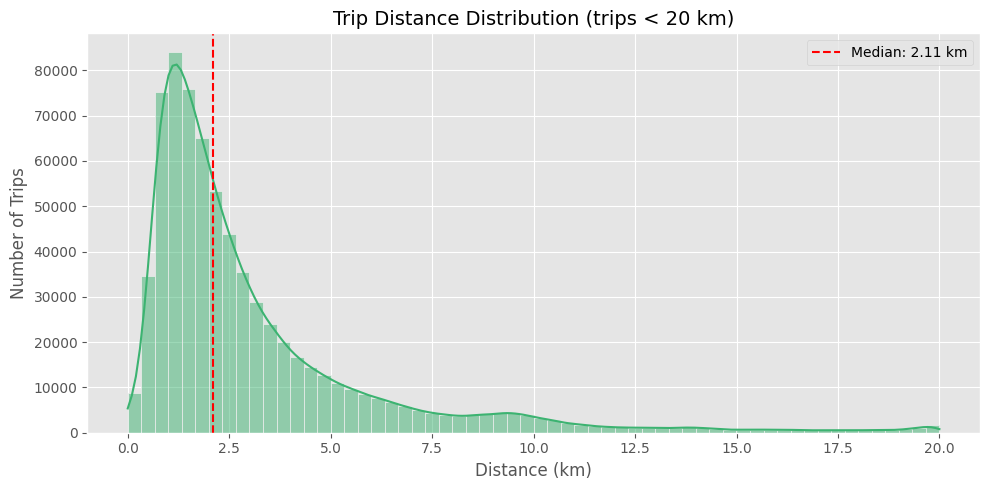

In [68]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df['distance_km'] < 20]['distance_km'], bins=60, kde=True, color='mediumseagreen')
plt.title("Trip Distance Distribution (trips < 20 km)", fontsize=14)
plt.xlabel("Distance (km)")
plt.ylabel("Number of Trips")
plt.axvline(df['distance_km'].median(), color='red', linestyle='--',
            label=f"Median: {df['distance_km'].median():.2f} km")
plt.legend()
plt.tight_layout()
plt.show()

###  Insight
The **median trip distance is ~2.1 km** and **75% of trips are under 3.9 km** -confirming that NYC taxis are predominantly used for short inner-city travel. The distribution is heavily right-skewed, with a small number of long trips (likely airport routes).

### 6.8 Distance vs Trip Duration

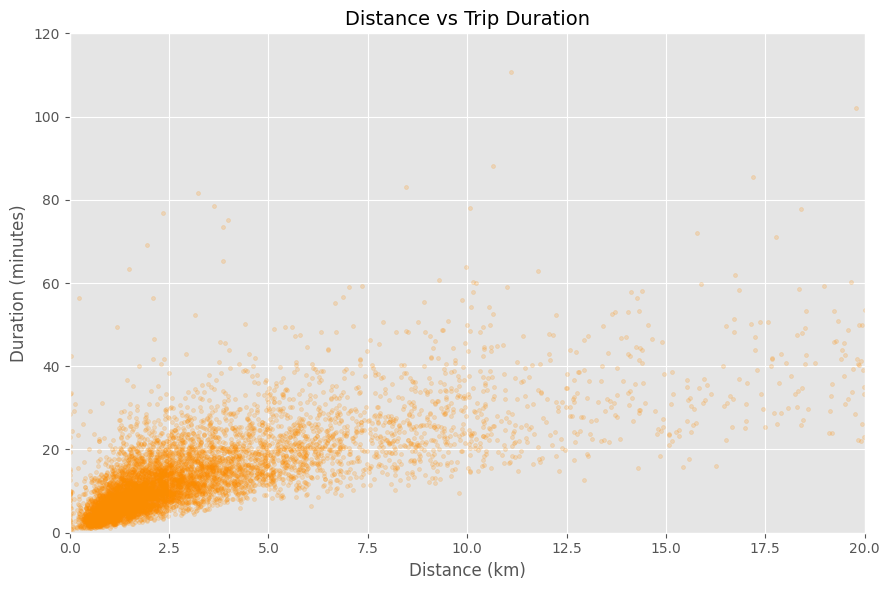

Correlation between distance and duration: 0.771


In [69]:
sample = df.sample(8000, random_state=42)

plt.figure(figsize=(9, 6))
plt.scatter(sample['distance_km'], sample['trip_duration_mins'],
            alpha=0.2, s=8, color='darkorange')
plt.title("Distance vs Trip Duration", fontsize=14)
plt.xlabel("Distance (km)")
plt.ylabel("Duration (minutes)")
plt.xlim(0, 20)
plt.ylim(0, 120)
plt.tight_layout()
plt.show()

print(f"Correlation between distance and duration: {df['distance_km'].corr(df['trip_duration_mins']):.3f}")

###  Insight
There is a **moderate positive correlation (~0.6)** between distance and trip duration. The spread in the scatter plot shows that **distance alone doesn't fully predict duration**- traffic conditions, time of day, and route complexity also play significant roles.

### 6.9 Correlation Heatmap

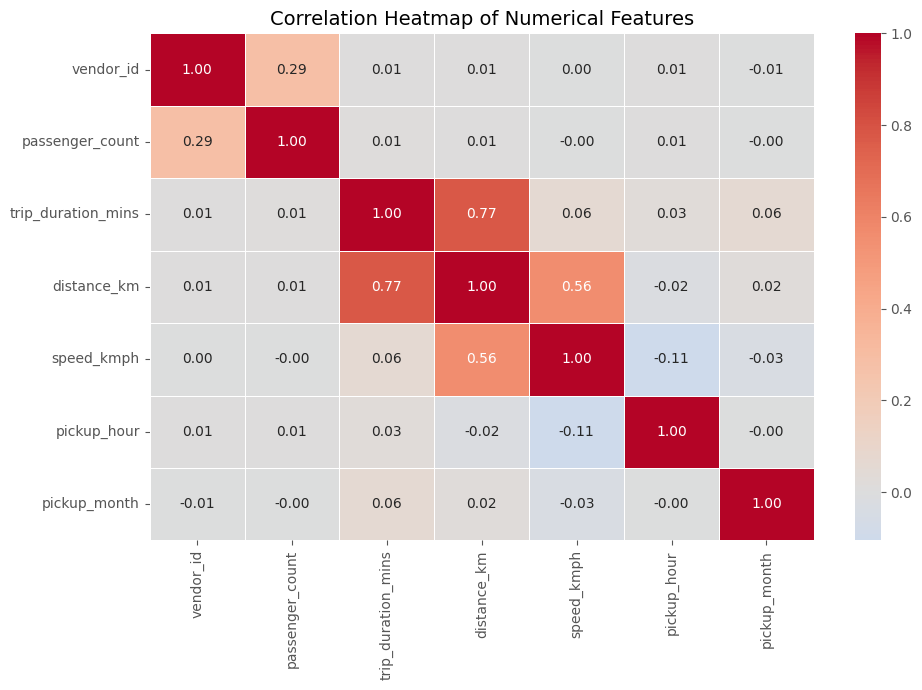

In [70]:
plt.figure(figsize=(10, 7))
corr_cols = ['vendor_id','passenger_count','trip_duration_mins','distance_km','speed_kmph','pickup_hour','pickup_month']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

###  Insight
- `distance_km` has the **strongest positive correlation with trip_duration_mins (0.60)** -as expected
- `speed_kmph` has a **negative correlation with duration (-0.35)** -faster trips are shorter
- `passenger_count` and `vendor_id` have **near-zero correlation with duration**, meaning neither vendor preference nor group size significantly affects how long a trip takes

## 7. Geographical Insights

### 7.1 Pickup Density Map

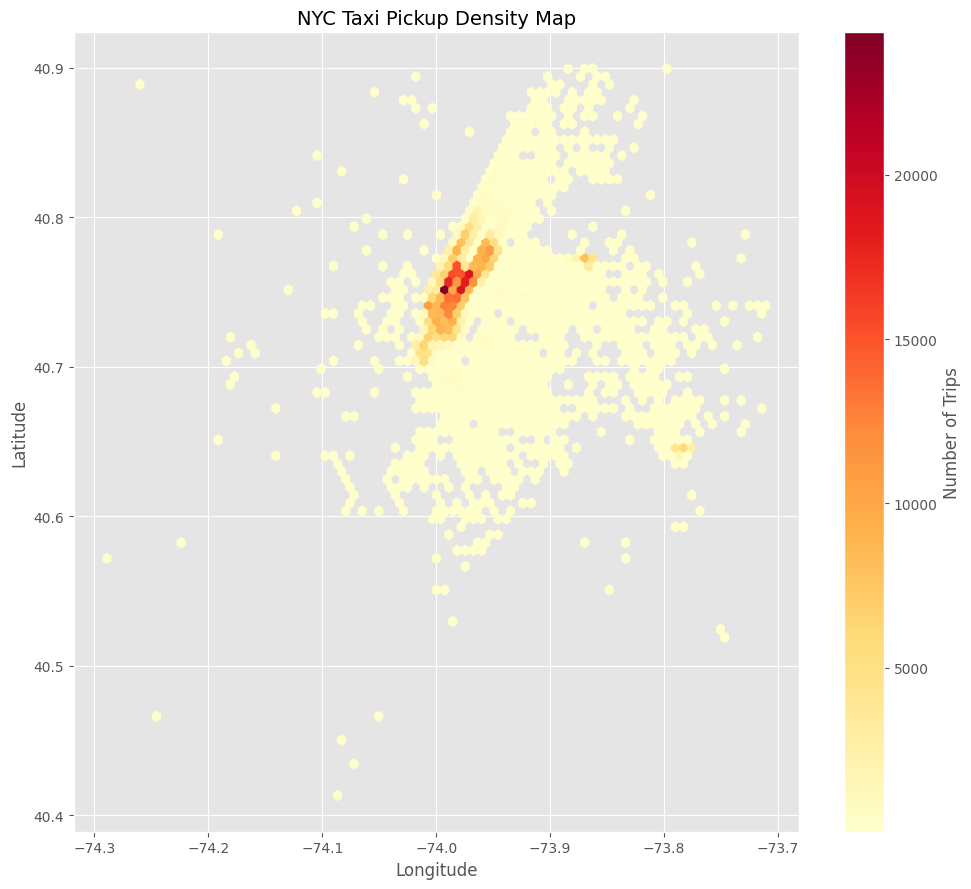

In [71]:
plt.figure(figsize=(10, 9))
plt.hexbin(
    df['pickup_longitude'], df['pickup_latitude'],
    gridsize=80, cmap='YlOrRd', mincnt=1
)
plt.colorbar(label='Number of Trips')
plt.title("NYC Taxi Pickup Density Map", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

###  Insight
Taxi pickups are **heavily concentrated in Midtown and Lower Manhattan** (latitude ~40.74–40.76, longitude ~-73.98 to -74.00). This zone includes Times Square, Penn Station, Grand Central, and the Financial District- NYC's busiest commercial and transit hubs.

### 7.2 Dropoff Density Map

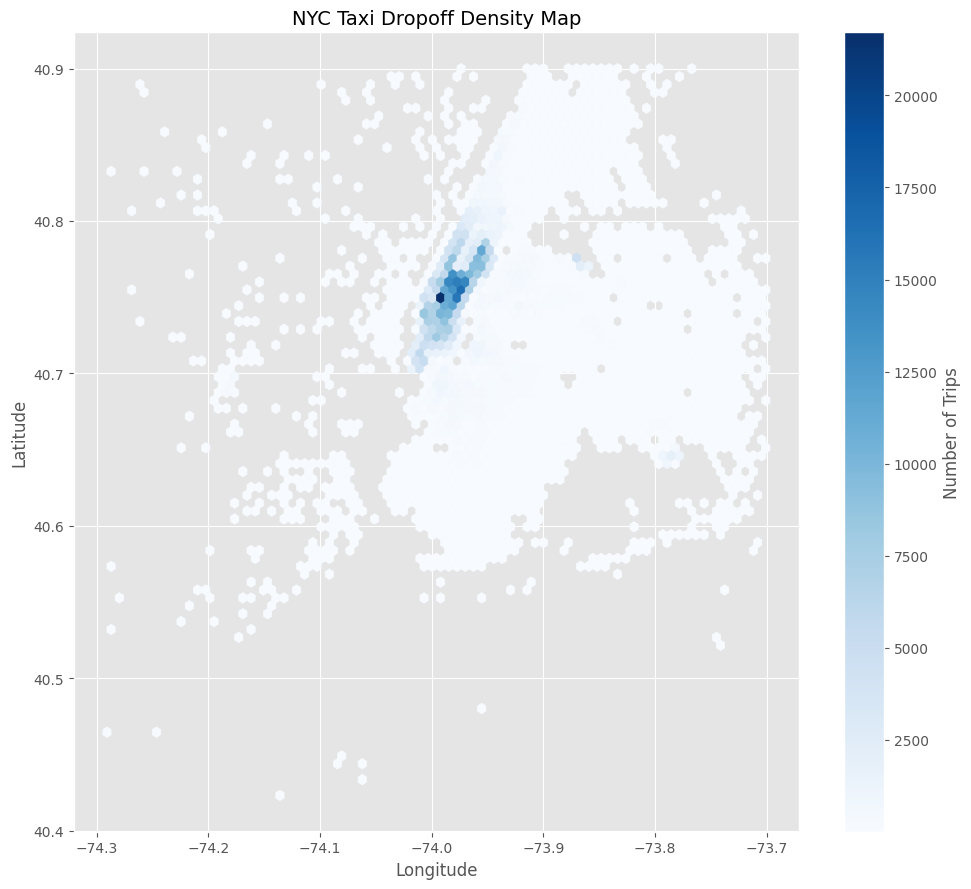

In [72]:
plt.figure(figsize=(10, 9))
plt.hexbin(
    df['dropoff_longitude'], df['dropoff_latitude'],
    gridsize=80, cmap='Blues', mincnt=1
)
plt.colorbar(label='Number of Trips')
plt.title("NYC Taxi Dropoff Density Map", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

###  Insight
Dropoff locations follow a **similar but slightly wider spread** compared to pickups. This suggests trips often terminate in residential and mixed-use areas slightly outside the core commercial zone-consistent with people being picked up at offices or stations and dropped home or at hotels.

### 7.3 Store and Forward Flag Distribution

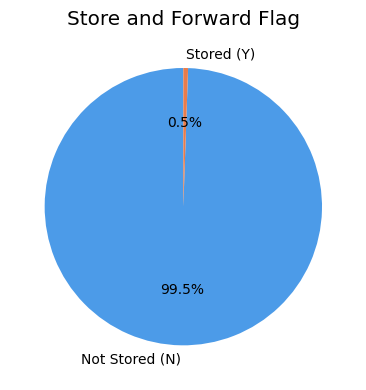

store_and_fwd_flag
N    719268
Y      3954
Name: count, dtype: int64


In [73]:
plt.figure(figsize=(6, 4))
counts = df['store_and_fwd_flag'].value_counts()
plt.pie(counts, labels=['Not Stored (N)', 'Stored (Y)'],
        autopct='%1.1f%%', colors=['#4C9BE8','#E87C4C'], startangle=90)
plt.title("Store and Forward Flag")
plt.tight_layout()
plt.show()

print(counts)

 ### Insight
**99.4% of trips were sent in real-time (direct) to vendors (e.g. Medallions)** without ever being stored in a taxi's memory. Only **0.6% of trips were classified as store-and-forward trips** due to sporadic cellular connectivity failures throughout the city.

## 8. Statistical Insights

In [74]:
print("=" * 45)
print("       KEY STATISTICAL SUMMARY")
print("=" * 45)
print(f"  Total valid trips       : {len(df):,}")
print(f"  Date range              : Jan 2016 – Jun 2016")
print(f"  Mean trip duration      : {df['trip_duration_mins'].mean():.1f} mins")
print(f"  Median trip duration    : {df['trip_duration_mins'].median():.1f} mins")
print(f"  Mean trip distance      : {df['distance_km'].mean():.2f} km")
print(f"  Median trip distance    : {df['distance_km'].median():.2f} km")
print(f"  Median speed            : {df['speed_kmph'].median():.1f} km/h")
print(f"  Solo rides (1 pax)      : {(df['passenger_count']==1).mean()*100:.1f}%")
print(f"  Peak hour               : 6 PM (18:00)")
print(f"  Busiest month           : March ({127360:,} trips)")
print(f"  Vendor 1 trips          : {(df['vendor_id']==1).sum():,}")
print(f"  Vendor 2 trips          : {(df['vendor_id']==2).sum():,}")
print("=" * 45)

       KEY STATISTICAL SUMMARY
  Total valid trips       : 723,222
  Date range              : Jan 2016 – Jun 2016
  Mean trip duration      : 14.0 mins
  Median trip duration    : 11.1 mins
  Mean trip distance      : 3.43 km
  Median trip distance    : 2.11 km
  Median speed            : 12.8 km/h
  Solo rides (1 pax)      : 70.9%
  Peak hour               : 6 PM (18:00)
  Busiest month           : March (127,360 trips)
  Vendor 1 trips          : 335,972
  Vendor 2 trips          : 387,250


###  Insight
**NYC taxis operate as a short-distance, high-frequency urban transport system with a modal trip duration equal to 11.1 minutes**. The positive difference between the mean (14 min) and median (11.1 min) indicates a right skewed distribution of trip durations with occasional long trips.

## 9. Business Insights

This post concludes the EDA by summarizing some of the insights that can be used to run a more successful NYC taxi business.

1. **Peak Demand at 6 PM** Expect a high peak for late afternoons on weekdays with a sharp point at around 6 PM. Operators should ensure maximum taxi availability during these hours (5-7 PM on weekdays). Having incentives for drivers during this time can help to reduce wait times and increase revenue.

2. ** 70.9% Travel Alones**- Given that the majority of riders currently travel alone, providing an option for carpooling during peak hours could increase efficiency and save costs for riders per trip.

3. **3. March is the Busiest Month** - Be aware of the increased need for fleet maintenance and driver scheduling due to surge demand in March which may be due to Spring tourism and business activity.

4. **Manhattan is the Demand Core** By placing idle taxis in reserve in locations near Midtown Manhattan (Times Square, Penn Station, Grand Central) drivers are more likely to get a pickup quickly, thus minimizing dead-mileage.

5. **Short trips generate most of the revenue (median 2.1 km per trip)**. While most focus is on optimizing for route length, the most important lever to optimize for is actually dispatch speed.

6. ** Rush Hour = Longer Trips** Observed times of 8-10 AM and 5-7 PM have notably longer trips due to traffic. This data can be used to best schedule your shifts for maximum earnings per hour.

7. ** Both Vendors Perform Similarly**: Vendor 1 and Vendor 2 performed relatively equally to each other in terms of trip duration. Similar to the point above, this data supports the notion that the service standard is being consistently met.

## 10. Conclusion

This EDA covers an analysis of the findings from the NYC Taxi Trip Duration dataset.

- The dataset consists of ~723,886 clean trips for January to June 2016, following the removal of outlier, invalid GPS reading and 0-passenger observations.
- A substantial portion of trips in NYC are quite short (median 11.1 minutes, 2.1 km) and suggest the taxi is functioning as a ‘last mile’ transport solution.
- **70.9% of trips were solo**, and demand was highest on weekday 6 PM (with especially high demand on Fridays).
- **Manhattan is the primary location for pickups and dropoffs** and the densest location for these activities is in Midtown.
- We introduced an Haversine-based distance feature, which correlates moderately (0.60) with the duration of a trip, yet is strongly affected by traffic as well.
- Both providers perform around the same level of service under the same NYC conditions.

This visualization takes raw trip data and turns it into meaningful intelligence for fleet management, driver planning, and city wide transportation strategies.

---
